Customer Churn Analysis 

In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import sqlite3

**sqlite** is database system that helps to work with sql database in python

In [2]:
#import data
conn = sqlite3.connect('customer_churn.db') #connects python with sqlite database
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""
tables = pd.read_sql(sql_query,conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT*FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")
conn.close()

created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


In [3]:
#print table names and columns names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # get column information
    columns_query = f"PRAGMA table_info({table_name});" 
    #PRAGMA table_info() is an SQLite command used to get information about a table's columns.
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())
#close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


**2. Data Cleaning**

first look at customer table

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [6]:
df_db_customer.isnull().sum()

customerid     0
name           0
country        3
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64

In [7]:
# first rename name column to customer name
df_db_customer.rename(columns = {"name":"customer_name"},inplace=True)

In [8]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [9]:
# above replace Women into Female and Men into Male
df_db_customer.replace({"Men":"Male","Women":"Female"},inplace=True)

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [10]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [11]:
# here pincode values are all null and interest of customer are not much important for churn analysis.
# so remove pincode and interest columns
df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [12]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [13]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 2.2 KB


In [14]:
# above you can see that dob column data type should be date but it is in str
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [15]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.8 KB


In [16]:
df_db_customer['state'].unique() # check unique values of state

<ArrowStringArray>
[  'Maharashtra',     'Karnataka',         'Delhi',      'Nagaland',
     'Meghalaya',     'Rajasthan',     'Kathmandu',     'Telangana',
 'Uttar Pradesh']
Length: 9, dtype: str

In [17]:
df_db_customer.isnull().sum() # checking null values

customerid       0
customer_name    0
country          3
state            0
gender           0
dob              0
dtype: int64

In [18]:
df_db_customer['country'].unique()

<ArrowStringArray>
['India', nan, 'Nepal']
Length: 3, dtype: str

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [20]:
# filling correct country name at null places
#country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer.isnull().sum()

customerid       0
customer_name    0
country          0
state            0
gender           0
dob              0
dtype: int64

now look at the table subscription

In [22]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [23]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [24]:
# above there are few null values in cancellation date which means customer has not cancelled the subscription that is good
# convert date column data type in date
date_colm = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_colm] = df_db_subscription[date_colm].apply(pd.to_datetime)

In [25]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


now look at customer support table

In [26]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [27]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [28]:
df_db_support['escalations'].unique()

<ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str

In [29]:
# droop col_1 because it is garbage
# drop comments as it not needed much here
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [30]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 690.0 bytes


In [31]:
#convert date time column data type
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [32]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


**3. Feature Engineering and Data analysis**

In [33]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [34]:
# create a new column - churn flag
#churn flag column which 1 for cancellation and 0 for not cancellation
df_db_subscription['churn flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [35]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0


In [36]:
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='str')

In [37]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score'], dtype='str')

In [38]:
# now we will merge three tables using customerid
df = (df_db_subscription
    .merge(df_db_customer,on = 'customerid',how = 'left')
    .merge(df_db_support,on = 'customerid', how = 'left'))

In [39]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [40]:
# very very important
df.shape

(23, 20)

In [41]:
df_db_subscription.shape

(21, 12)

In [42]:
df_db_support.shape

(9, 4)

In [43]:
df_db_customer.shape

(21, 6)

In [44]:
# in subcription table there are only 21 rows while after left merging 2 more rows added means duplciation in data
df_db_subscription['customerid'].nunique() # it is not changing qfter merging

21

In [45]:
df_db_customer['customerid'].nunique() # after merging it is also right

21

In [46]:
df_db_support['customerid'].nunique() # here in this 2 rows increases

7

In [47]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [48]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [49]:
df_db_support['complaint_count'] # here it gives the count according to the duplicate customerid 

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: complaint_count, dtype: int64

In [50]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')
# drop duplicate colmid and keep only last value from duplicate value

In [51]:
df_db_support['complaint_count'] # check the duplicate values. is it removed ?

2    1
5    1
1    2
8    2
6    1
4    1
3    1
Name: complaint_count, dtype: int64

In [52]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [53]:
# now merge the tables again
df = (df_db_subscription
    .merge(df_db_customer,on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [54]:
df.shape

(21, 21)

In [55]:
df_db_subscription.shape

(21, 12)

In [56]:
# above as can see now rows are not duplicated (no extra row)

In [57]:
# lets convert df into csv file to view the data in excel
df.to_csv("exported_churn_data.csv",index=False)

**Data Analysis**

churn rate -> how many customer going to leave

In [58]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

churn rate =  (no. of churn customers)/(total customers)
or you can say that mean

In [59]:
#1. churn rate 
churn_rate = df['churn flag'].mean()*100
print("churn rate:", round(churn_rate,2), "%")

churn rate: 28.57 %


In [60]:
#2. retention rate -> how many are not churn customers
retention_rate = 100 - churn_rate
print("retention rate:", round(retention_rate,2), "%")

retention rate: 71.43 %


In [61]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [62]:
df['plan_type'].unique()

<ArrowStringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [63]:
# now try to find from which plan most of the customer are churning and what are the loss 
churn_by_plan = (df.groupby('plan_type')['churn flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [64]:
df[df['churn flag'] == 1].groupby('plan_type')['monthly_charges'].sum().reset_index(name='total rev loss')

,plan_type,total rev loss
0,Basic,38.97
1,Premium,12.99
2,Standard,21.98


In [65]:
df[df['churn flag'] == 1].groupby('plan_type')['plan_type'].value_counts().reset_index(name='no. of churn user')

,plan_type,no. of churn user
0,Basic,3
1,Premium,1
2,Standard,2


In [66]:
# summary of the churn by each plan type
plan_summary = (
    df.groupby('plan_type')
      .agg(
          total_customers=('churn flag', 'count'),
          churned_customers=('churn flag', 'sum'),
          churn_rate_pct=('churn flag', lambda x: round(x.mean() * 100, 2)),
          monthly_revenue=('monthly_charges', 'sum'),
          revenue_loss=('monthly_charges',
                        lambda x: x[df.loc[x.index, 'churn flag'] == 1].sum())
      )
      .reset_index()
)

print(plan_summary)

  plan_type  total_customers  churned_customers  churn_rate_pct  \
0     Basic                5                  3           60.00   
1   Premium                7                  1           14.29   
2  Standard                9                  2           22.22   

   monthly_revenue  revenue_loss  
0            52.95         38.97  
1           218.93         12.99  
2           123.91         21.98  


In this dataset, Basic has the highest observed churn rate (60%) and the highest monthly revenue loss among the three plans.

In [67]:
# summary of the churn by each state
state_summary = (
    df.groupby('state')
      .agg(
          total_customers=('churn flag', 'count'),
          churned_customers=('churn flag', 'sum'),
          churn_rate_pct=('churn flag', lambda x: round(x.mean() * 100, 2)),
          monthly_revenue=('monthly_charges', 'sum'),
          revenue_loss=('monthly_charges',
                        lambda x: x[df.loc[x.index, 'churn flag'] == 1].sum())
      )
      .reset_index()
)

print(state_summary)

           state  total_customers  churned_customers  churn_rate_pct  \
0          Delhi                4                  1           25.00   
1      Karnataka                2                  2          100.00   
2      Kathmandu                2                  0            0.00   
3    Maharashtra                3                  0            0.00   
4      Meghalaya                3                  2           66.67   
5       Nagaland                1                  0            0.00   
6      Rajasthan                2                  0            0.00   
7      Telangana                2                  1           50.00   
8  Uttar Pradesh                2                  0            0.00   

   monthly_revenue  revenue_loss  
0            52.96         13.99  
1            20.98         20.98  
2            20.98          0.00  
3            50.97          0.00  
4            42.97         21.98  
5            22.99          0.00  
6            36.98          0.00  

**State-level analysis shows variation in observed churn rates. Karnataka has a 100% churn rate in the dataset, but this is based on only two customers. Meghalaya has a 66.67% churn rate and the highest observed revenue loss among the states shown (as it is a small dataset)**

In [68]:
# summary of the churn by each subscription_type
subscription_summary = (
    df.groupby('subscription_type')
      .agg(
          total_customers=('churn flag', 'count'),
          churned_customers=('churn flag', 'sum'),
          churn_rate_pct=('churn flag', lambda x: round(x.mean() * 100, 2)),
          monthly_revenue=('monthly_charges', 'sum'),
          revenue_loss=('monthly_charges',
                        lambda x: x[df.loc[x.index, 'churn flag'] == 1].sum())
      )
      .reset_index()
)

print(subscription_summary)

  subscription_type  total_customers  churned_customers  churn_rate_pct  \
0           Organic                9                  0            0.00   
1              Paid                6                  1           16.67   
2          Refferal                6                  5           83.33   

   monthly_revenue  revenue_loss  
0           145.91          0.00  
1           174.94         12.99  
2            74.94         60.95  


Based on the available dataset, the Referral subscription group has the highest observed churn rate at 83.33% (5 out of 6 customers) and the highest revenue loss of 60.95. The Organic group has 0% observed churn, while the Paid group has a 16.67% observed churn rate

In [69]:
#ARPU -> avg revenue per user
arpu = df['monthly_charges'].mean()
print("ARPU =", round(arpu,2))

ARPU = 18.85


In [70]:
# avg customer Tenure
# count of days user has used our service till cancellation date or current date
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure_days = df['tenure_days'].mean()
print("average tenure days:", round(avg_tenure_days,0))

average tenure days: 1550.0


In [71]:
# revenue at risk -> revenue lost from churned users
rev_at_risk = df.loc[df['churn flag'] == 1, 'monthly_charges'].sum()
print("revenue at risk (Rs K):", rev_at_risk)

revenue at risk (Rs K): 73.94


In [72]:
# Escalation rate -> customer who complained but their query not solved
df['escalations'].unique()

<ArrowStringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str

In [73]:
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("escalation rate:", round(escalation_rate,2), "%")

escalation rate: 19.05 %


In [74]:
# avg compalint per user
avg_comp = df['complaint_count'].sum()/df['customerid'].nunique()
print("avg complaints per user =", round(avg_comp,2))

avg complaints per user = 0.43


In [75]:
# correlation Escalation vs churn
df[['escalations','churn flag']].dropna()

,escalations,churn flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [76]:
# to find corr we have convert escalation in numeric value (Y -> 1, N -> 0)
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)
corr_df = df[['escalations','churn flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn flag'])


In [77]:
print("correlation between escalations vs churn:", round(correlation,2))

correlation between escalations vs churn: 0.77


In [78]:
#create a column churn risk using churn score
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low','mid','high']
df['churn_risk'] = np.select(conditions,choices,default = 'unknown')
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


**Data Visualization**

In [79]:
df_vis = df.copy() # copy original data so that original data remain as it is

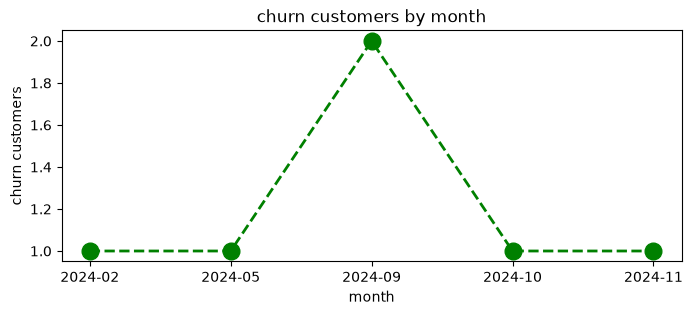

In [80]:
df_vis['cancellation_month'] = df_vis['cancellation_date'].dt.to_period('M')
churn_trend = df_vis[df_vis['churn flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.xlabel('month')
plt.ylabel('churn customers')
plt.title("churn customers by month")
plt.plot(churn_trend.index.astype(str),churn_trend.values, color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)
plt.show()

2. Churn by plan type

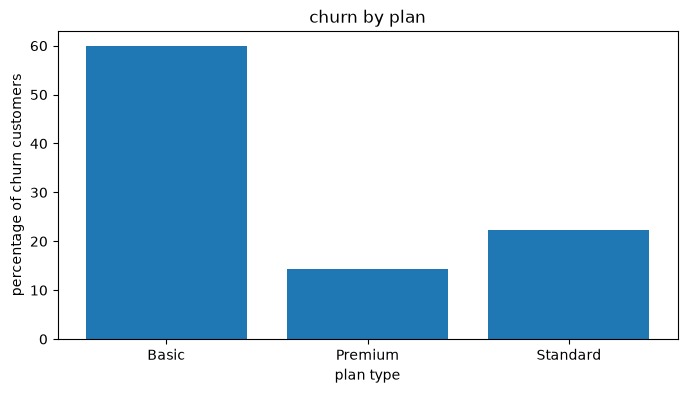

In [81]:
churn_plan = df_vis.groupby('plan_type')['churn flag'].mean()*100
plt.figure(figsize=(8,4))
plt.ylabel("percentage of churn customers")
plt.xlabel("plan type")
plt.title("churn by plan")
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

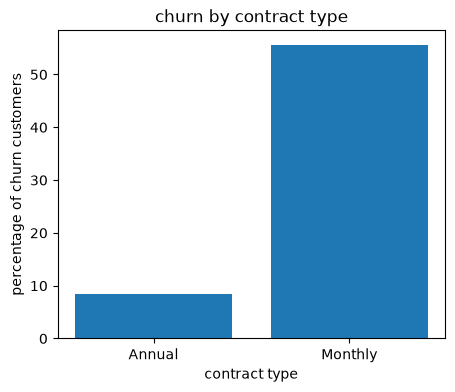

In [82]:
contract_plan = df_vis.groupby('contract_type')['churn flag'].mean()*100
plt.figure(figsize=(5,4))
plt.ylabel("percentage of churn customers")
plt.xlabel("contract type")
plt.title("churn by contract type")
plt.bar(contract_plan.index,contract_plan.values)
plt.show()

In [84]:
# correlation visualization using seaborn
# encoding -> convert str to numeric so that we can find corr between feaatures
df_vis.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [87]:
df_vis[['plan_type','contract_type','churn_score','churn flag', 'churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [96]:
df_encoded = df_vis[['plan_type','contract_type','churn_score','churn flag', 'churn_risk','escalations']]
# str to numerical by priority based
order_map = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','mid','high']
}
# key idea: String → Category → Ordered Category → Numeric code
for col,order in order_map.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [97]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

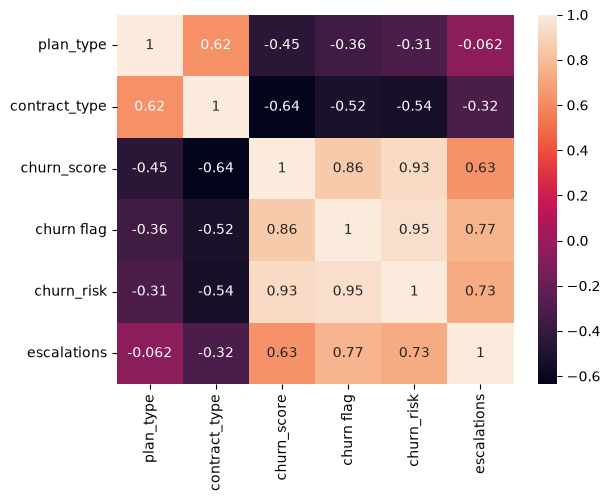

In [98]:
sns.heatmap(df_encoded.corr(),annot=True)

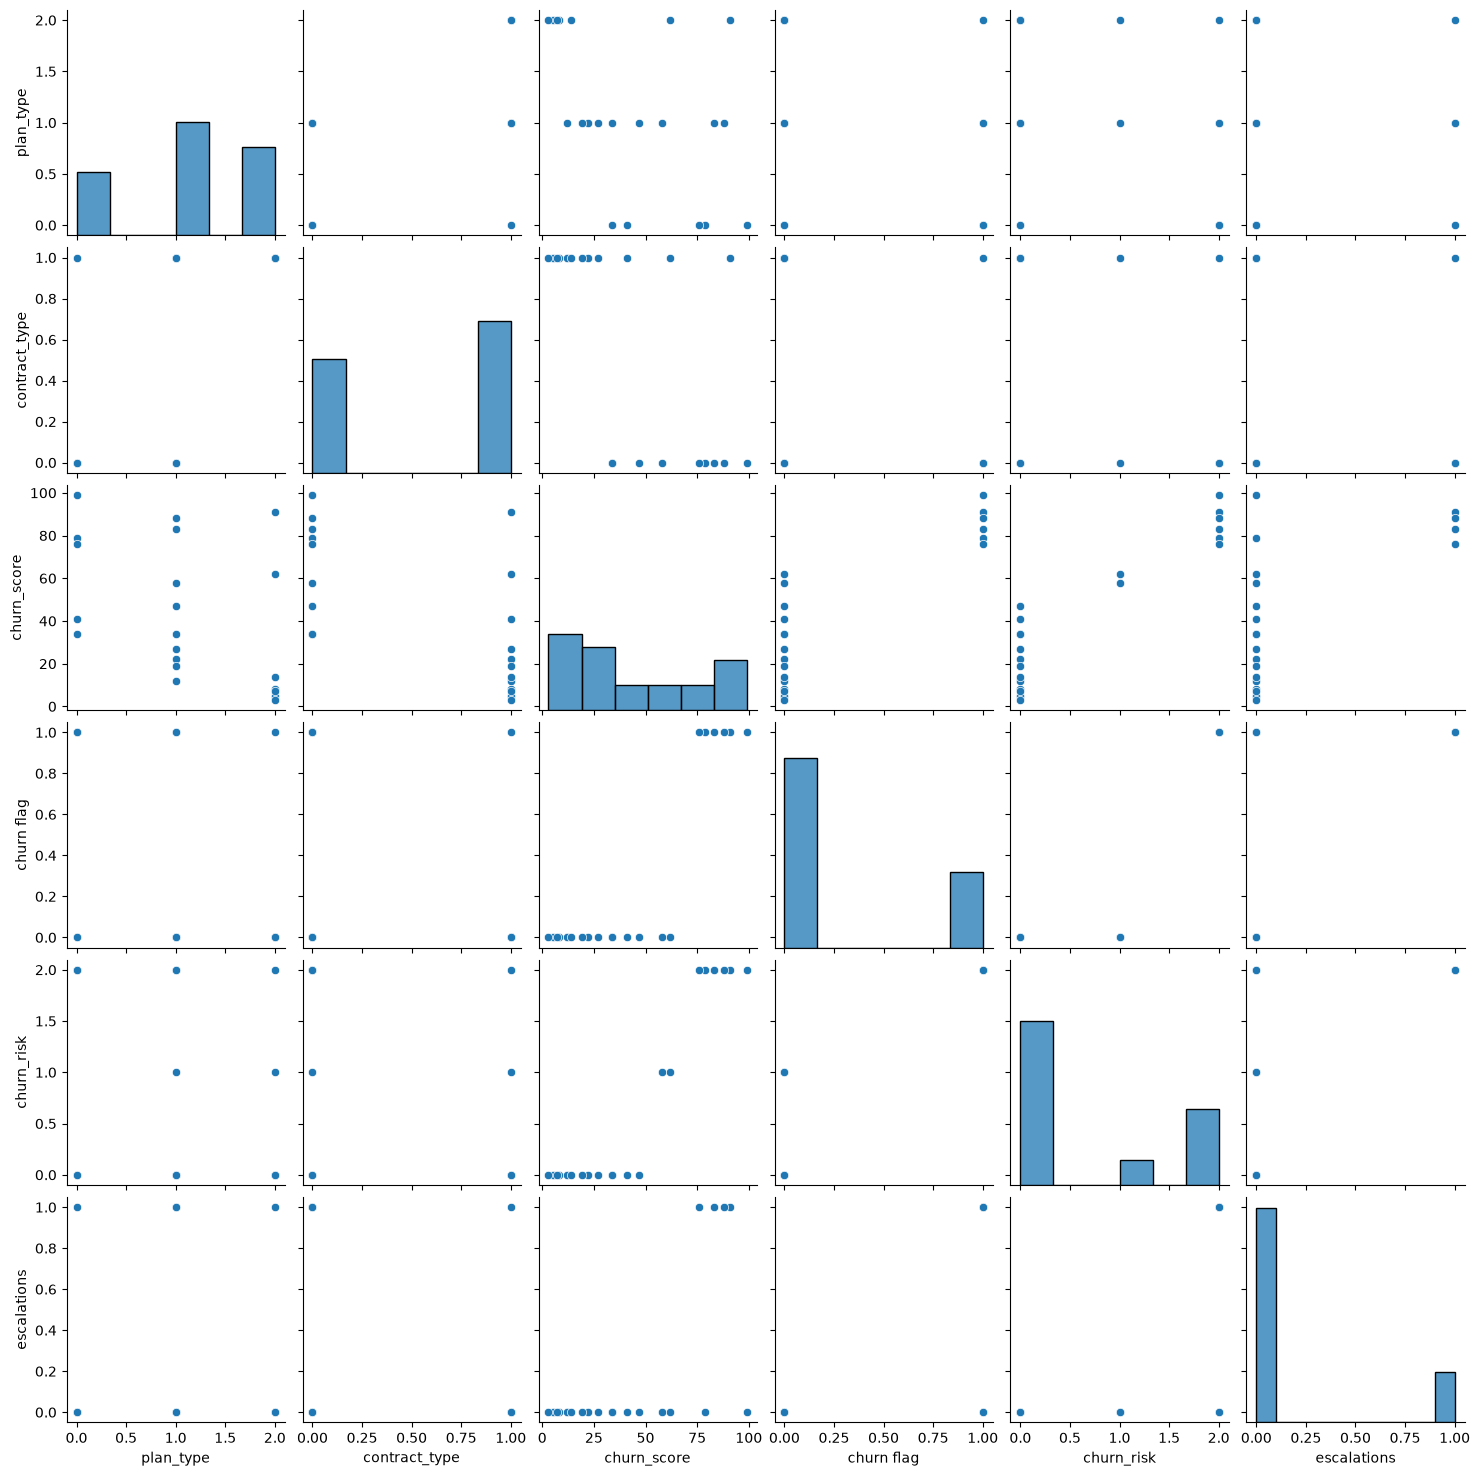

In [99]:
# pair plot
sns.pairplot(df_encoded)

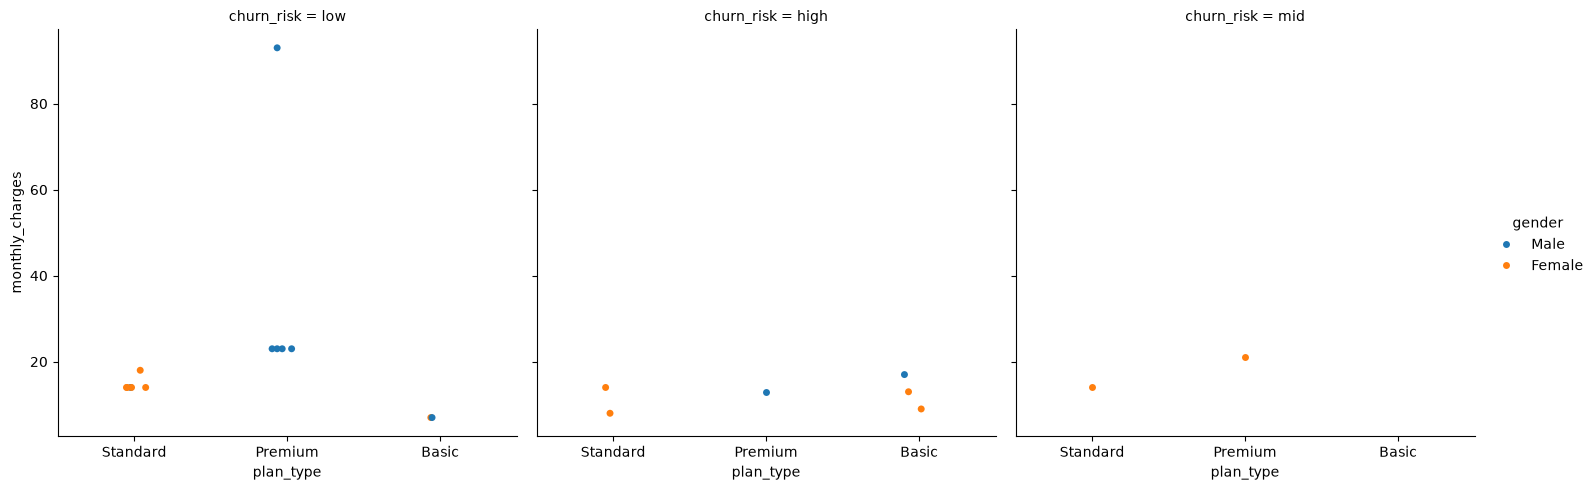

In [101]:
#catplt / Facegrid plot - mutli dim comparison
sns.catplot(data = df_vis,
           x = 'plan_type',
           y= 'monthly_charges',
           hue = 'gender',
           col = 'churn_risk')

In [106]:
# pivot table
pd.pivot_table(
    df_vis,
    index = 'plan_type',
    values = ['monthly_charges', 'customerid', 'churn flag'],
    aggfunc = {
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn flag':'mean'
    }
)

,churn flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
